# Modèle pour la prédiction du débit d'entrée pour la station C

## Imports

In [8]:
# Installation de XGBoost + dépendances (à exécuter une seule fois)
import sys
import subprocess

print(f"📍 Python utilisé : {sys.executable}")
print("📦 Installation de libomp (dépendance pour XGBoost sur macOS)...")

# Installation de libomp via Homebrew (nécessaire sur macOS)
result_brew = subprocess.run(
    ["brew", "install", "libomp"],
    capture_output=True,
    text=True
)

if result_brew.returncode == 0 or "already installed" in result_brew.stdout.lower():
    print("✅ libomp installé ou déjà présent")
else:
    print("⚠️ Homebrew non trouvé ou erreur, essai d'une installation alternative...")

print("\n📦 Installation de XGBoost...")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "xgboost"],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print("✅ XGBoost installé avec succès !")
    print("\n🔄 Redémarrez maintenant le kernel du notebook (bouton 'Restart' en haut)")
else:
    print("❌ Erreur d'installation :")
    print(result.stderr)

📍 Python utilisé : /Users/nbieszczad/M2DS/Capstone VINCI/.venv/bin/python
📦 Installation de libomp (dépendance pour XGBoost sur macOS)...
✅ libomp installé ou déjà présent

📦 Installation de XGBoost...
✅ libomp installé ou déjà présent

📦 Installation de XGBoost...
✅ XGBoost installé avec succès !

🔄 Redémarrez maintenant le kernel du notebook (bouton 'Restart' en haut)
✅ XGBoost installé avec succès !

🔄 Redémarrez maintenant le kernel du notebook (bouton 'Restart' en haut)


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb  
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Données 

In [13]:
# Capteurs
df_sensors = pd.read_csv('/Users/nbieszczad/M2DS/Capstone VINCI/Capstone/Dataset/bronze/sensors_C_20210101_20250101.csv')
df_sensors['ts'] = pd.to_datetime(df_sensors['ts'])

# Débit d'entrée 
df_debit = df_sensors[df_sensors['sensor'] == 'entry_debit'].copy()
df_debit = df_debit.set_index('ts')[['value']].resample('1h').mean() # Le débit est agrégé à l'échelle horaire car les données météo sont à cett échelle.
df_debit.columns = ['debit']

# Météo : dans un premier temps, on va essayer en faisant la moyenne des 14 villes
weather_files = [
    'Aiglemont', 'Chalandry-Elaire', 'Damouzy', 'Dom-le-Mesnil',
    'Flize', 'La-Francheville', 'La-Grandville', 'Les-Ayvelles',
    'Montcy-Notre-Dame', 'Prix-les-Mezieres', 'Saint-Laurent',
    'Ville-sur-Lumes', 'Villers-Semeuse', 'Warcq'
]

weather_frames = []
for city in weather_files:
    try:
        df = pd.read_csv(f'/Users/nbieszczad/M2DS/Capstone VINCI/Capstone/Dataset/bronze/weather_C/{city}_hourly.csv')
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')[['temperature_2m', 'rain', 'wind_speed_10m']].resample('1h').mean()
        weather_frames.append(df)
    except:
        pass

df_weather = pd.concat(weather_frames).groupby(level=0).mean()
if df_weather.index.tz: df_weather.index = df_weather.index.tz_localize(None)

# Fusion
df = pd.merge(df_debit, df_weather, left_index=True, right_index=True, how='inner')


### Features 

In [21]:
# 1. Pluie décalée (LAG 5h) 
df['rain_lag_5'] = df['rain'].shift(5)

# 2. Features temporelles
df['hour'] = df.index.hour
df['month'] = df.index.month

# Encodage cyclique (pour capturer la continuité 23h → 0h). Sans ca, le modele ne pourra pas faire de lien entre 23h et 00H par exemple. 
# Ca va aussi faire que le modele va potentiellement mettre plus de poids sur 23h que 00h car 23>0
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# 3. Lags du débit (inertie hydraulique)
df['debit_lag_1h'] = df['debit'].shift(1)
df['debit_lag_6h'] = df['debit'].shift(6)                     #Est ce que ca veut dire qu'on injecte de la donnée passée alors qu'on est censé prédire avec les infos à t-1?
df['debit_lag_24h'] = df['debit'].shift(24)

# 4. Rolling Statistics (fenêtres glissantes) 
df['debit_roll_mean_24h'] = df['debit'].rolling(window=24, min_periods=1).mean()
df['rain_roll_sum_12h'] = df['rain'].rolling(window=12, min_periods=1).sum()

# 5. Interactions métier
df['temp_x_rain'] = df['temperature_2m'] * df['rain_lag_5']  # Pluie chaude vs froide
df['wind_x_rain'] = df['wind_speed_10m'] * df['rain_lag_5']  # Tempêtes

# 6. Features binaires
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)

# Suppression des NaN (dus aux lags)
df_clean = df.dropna()

print(f"Dataset final : {len(df_clean):,} heures")
print(f"Période : {df_clean.index.min()} → {df_clean.index.max()}")
print(f"Features créées : {df_clean.shape[1] - 1} (hors cible)")


Dataset final : 33,368 heures
Période : 2021-01-02 00:00:00 → 2024-12-31 23:00:00
Features créées : 18 (hors cible)


### Train/test split

In [22]:
split_date = df_clean.index.max() - pd.DateOffset(months=6)
train = df_clean[df_clean.index < split_date]
test = df_clean[df_clean.index >= split_date]

# Séparation X/y
feature_cols = [
    'temperature_2m', 'rain', 'wind_speed_10m', 'rain_lag_5',
    'hour', 'month',
    'sin_hour', 'cos_hour', 'sin_month', 'cos_month',
    'debit_lag_1h', 'debit_lag_6h', 'debit_lag_24h', 
    'debit_roll_mean_24h', 'rain_roll_sum_12h',       
    'temp_x_rain', 'wind_x_rain',
    'is_night'
]

X_train = train[feature_cols]
y_train = train['debit']
X_test = test[feature_cols]
y_test = test['debit']

print(f" Train: {len(train):,} | Test: {len(test):,} ({len(test)/len(train)*100:.1f}%)")

 Train: 28,979 | Test: 4,389 (15.1%)


### Prédiction

In [23]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,  # Régularisation
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Évaluation

In [24]:
y_pred = model.predict(X_test)

# Métriques
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n🎯 RÉSULTATS")
print(f"{'='*50}")
print(f"RMSE : {rmse:.2f} m³/h")
print(f"MAE  : {mae:.2f} m³/h")
print(f"R²   : {r2:.3f}")
print(f"{'='*50}")


🎯 RÉSULTATS
RMSE : 95.47 m³/h
MAE  : 56.86 m³/h
R²   : 0.937



🔍 IMPORTANCE DES FEATURES (Top 10)
debit_lag_1h              0.5554  ███████████████████████████████████████████████████████
debit_roll_mean_24h       0.1890  ██████████████████
debit_lag_6h              0.0633  ██████
is_night                  0.0317  ███
debit_lag_24h             0.0293  ██
rain_roll_sum_12h         0.0269  ██
hour                      0.0159  █
cos_month                 0.0130  █
month                     0.0128  █
wind_x_rain               0.0119  █


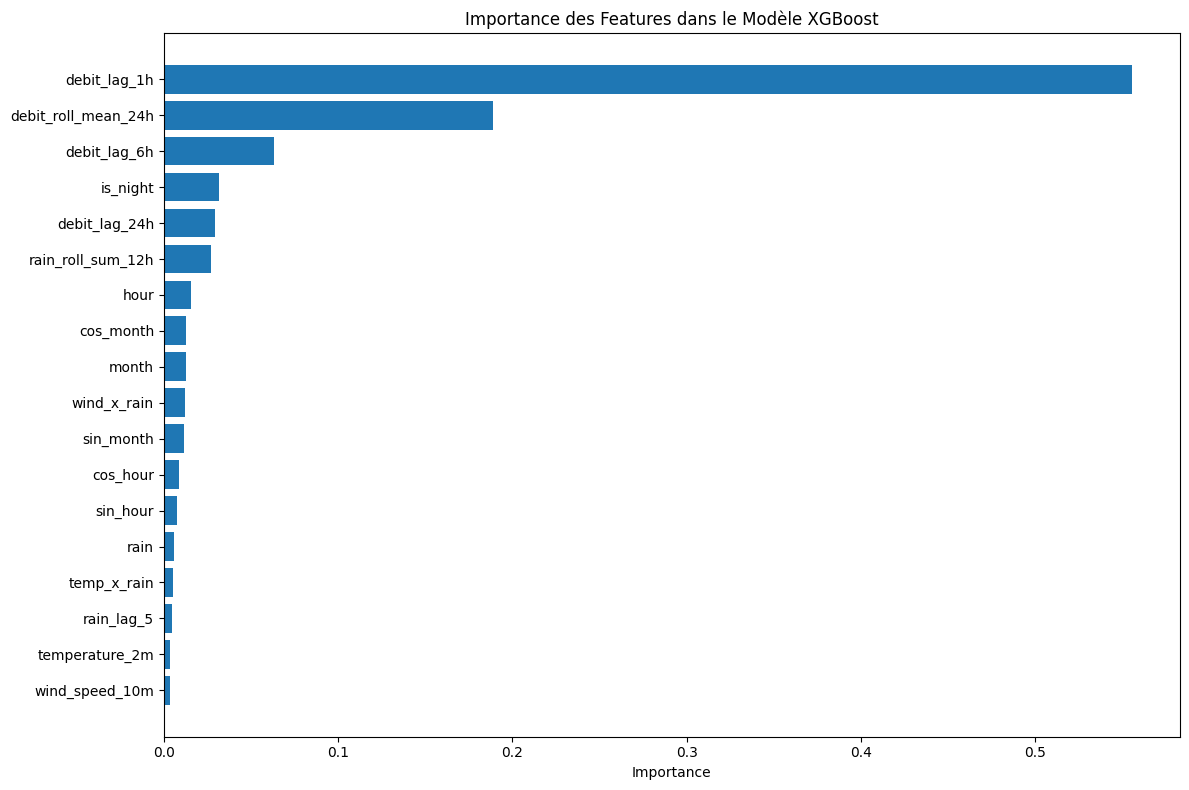


💡 % de variance expliquée par les TOP features :
   debit_lag_1h seul      : 55.5%
   TOP 3 features cumulés : 80.8%
   TOP 5 features cumulés : 86.9%


In [26]:
# Récupération des importances
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Affichage
print("\n🔍 IMPORTANCE DES FEATURES (Top 10)")
print(f"{'='*60}")
for idx, row in feature_importance.head(10).iterrows():
    print(f"{row['feature']:<25} {row['importance']:.4f}  {'█' * int(row['importance'] * 100)}")
print(f"{'='*60}")

# Visualisation
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Importance des Features dans le Modèle XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Calcul du % cumulé
feature_importance['cumulative'] = feature_importance['importance'].cumsum() / feature_importance['importance'].sum()
print(f"\n💡 % de variance expliquée par les TOP features :")
print(f"   debit_lag_1h seul      : {feature_importance.iloc[0]['importance']:.1%}")
print(f"   TOP 3 features cumulés : {feature_importance.iloc[:3]['cumulative'].values[-1]:.1%}")
print(f"   TOP 5 features cumulés : {feature_importance.iloc[:5]['cumulative'].values[-1]:.1%}")